In [1]:
#! pip install tabula-py
import warnings
warnings.filterwarnings('ignore')

from cluster_functions import *

import pandas as pd
import numpy as np
import camelot
import seaborn as sns
from matplotlib import pyplot as plt


pallete = 'viridis'
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
font = {'color':  'black', 'weight': 'normal','size': 14}

patch = r'C:\\Users\\Ruan\\Desktop\\Mestrado\\Referencias\\'

data = pd.read_csv('Dados/data.csv', index_col='Cluster')
df = pd.read_csv('Dados/results.csv', index_col='Cluster')


In [35]:
Niu = pd.read_csv(patch + "Niu.txt", index_col='Cluster')
Niu = Niu[['fbin', 'fbin_err']]

donada = pd.read_fwf(patch + 'Donada.dat',)
donada.loc[donada.shape[0]]=donada.columns
colunas = ['Cluster','RAdeg','DEdeg','GLON','GLAT','r50',\
           'plx','e_plx','logAgeNN','AVNN','DistPc',\
           'X','Y','Z','Rgc','nbMSmemb','BP-RP0min',\
          'BP-RP0max','MSwidth','MassMin','MassMax','MassMean',\
          'fbqlim0.6', 'E_fbqlim0.6', 'e_fbqlim0.6',\
          'DG','E_DG', 'e_DG', 'sS','E_sS','e_sS', 'sB','E_sB',\
          'e_sB','fbtotqlim0.6','E_fbtotqlim0.6','e_fbtotqlim0.6']
donada.columns=colunas
donada.index=donada['Cluster']
donada.drop(columns='Cluster', inplace=True)
donada['fbtotqlim0.6'] = donada['fbtotqlim0.6'].astype(float)
donada['e_fbtotqlim0.6'] = donada['e_fbtotqlim0.6'].astype(float)
donada.sort_index(inplace=True)
donada = donada[['fbtotqlim0.6', 'e_fbtotqlim0.6']]


Jedvahj = pd.read_csv(patch + 'Jedvahj.txt',sep=',', index_col=None)
Jedvahj['Name'] = Jedvahj.index
Jedvahj.replace(to_replace=' ', value='_', regex=True, inplace= True)
Jedvahj.index=Jedvahj['Name']
Jedvahj = Jedvahj[['fb']]

Jiang = pd.read_csv(patch + 'Jiang.txt',sep=',', index_col='Name_ref')
#Jiang = Jiang[['fb']]

Li_Shao = pd.read_csv(patch+ 'Li_Shao.csv', index_col = 'Cluster')

In [3]:
qs = [0, 0.2, 0.5, 0.6]
columns = ['bin_frac','bin_frac_02','bin_frac_05', 'bin_frac_06']

df_comp = pd.DataFrame(columns=columns, index=data.index.unique())
for cluster in data.index.unique():
    for i in range(0, len(qs)):
        df.loc[cluster, columns[i]] = bin_frac(data.loc[cluster], qs[i])


for cluster in data.index.unique():
    for i in range(0, len(qs)):
        df_comp.loc[cluster, columns[i]] = corr_fb(df, cluster, qs[i])
df_comp = df_comp.astype(float)

In [4]:
for cluster in donada.index:
    if cluster in df_comp.index:
        donada.loc[cluster, 'bin_frac_06'] = df_comp.loc[cluster, 'bin_frac_06']

for cluster in Jedvahj.index:
    if cluster in df_comp.index:
        Jedvahj.loc[cluster, 'bin_frac_06'] = df_comp.loc[cluster, 'bin_frac_06']

for cluster in Jiang.index:
    if cluster in df_comp.index:
        Jiang.loc[cluster, 'bin_frac_05'] = df_comp.loc[cluster, 'bin_frac_05']

for cluster in Li_Shao.index:
    if cluster in df_comp.index:
        Li_Shao.loc[cluster, 'bin_frac_02'] = df_comp.loc[cluster, 'bin_frac_02']
        
for cluster in Niu.index:
    if cluster in df_comp.index:
        Niu.loc[cluster, 'bin_frac'] = df_comp.loc[cluster, 'bin_frac']




donada.dropna(inplace=True)
Jedvahj.dropna(inplace=True)
Jiang.dropna(inplace=True)
Li_Shao.dropna(inplace=True)
Niu.dropna(inplace=True)



In [5]:
donada.describe().round(2)

,fbtotqlim0.6,bin_frac_06
count,112.00,112.00
mean,0.22,0.27
std,0.13,0.06
min,0.06,0.15
25%,0.13,0.22
50%,0.17,0.26
75%,0.24,0.30
max,0.80,0.51


In [6]:
Jedvahj.describe().round(2)

,fb,bin_frac_06
count,7.00,7.00
mean,0.19,0.22
std,0.02,0.04
min,0.17,0.19
25%,0.17,0.20
50%,0.19,0.21
75%,0.22,0.21
max,0.22,0.32


In [7]:
Jiang.describe().round(2)

,fb,bin_frac_05
count,17.00,17.00
mean,0.16,0.31
std,0.03,0.07
min,0.12,0.18
25%,0.15,0.26
50%,0.16,0.32
75%,0.17,0.37
max,0.21,0.43


In [8]:
Li_Shao.describe().round(2)

,fb,bin_frac_02
count,5.00,5.00
mean,0.40,0.46
std,0.06,0.07
min,0.30,0.38
25%,0.40,0.40
50%,0.41,0.46
75%,0.44,0.53
max,0.46,0.55


In [9]:
Niu.describe().round(2)

,fbin,bin_frac
count,8.00,8.00
mean,43.75,0.48
std,8.48,0.09
min,29.00,0.35
25%,40.25,0.43
50%,43.00,0.47
75%,48.75,0.54
max,55.00,0.62


In [10]:
df_comp.bin_frac.describe().round(2)

count    771.00
mean       0.51
std        0.05
min        0.30
25%        0.49
50%        0.52
75%        0.54
max        0.73
Name: bin_frac, dtype: float64

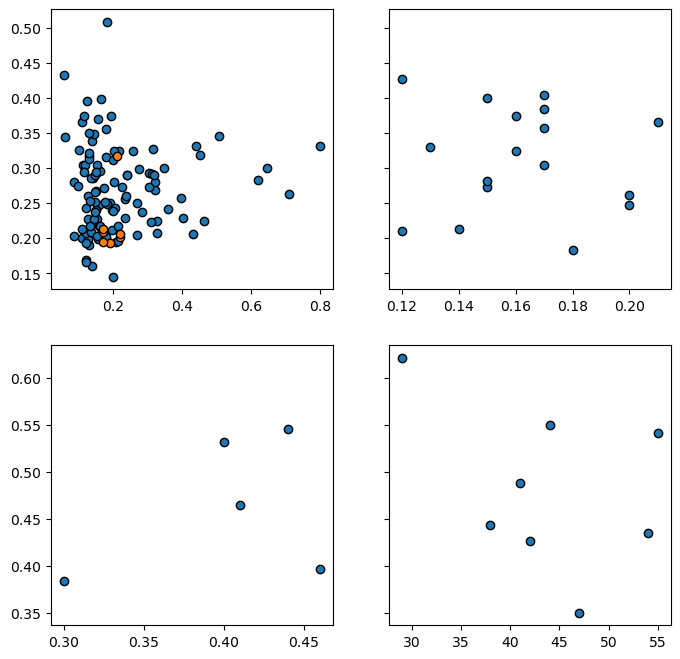

In [26]:
fig, ax = plt.subplots(2,2, figsize=(8,8), sharey='row',)

ax[0,0].scatter(donada['fbtotqlim0.6'], donada['bin_frac_06'], edgecolor='k', )
ax[0,0].scatter(Jedvahj['fb'], Jedvahj['bin_frac_06'], edgecolor='k',)
ax[0,1].scatter(Jiang['fb'], Jiang['bin_frac_05'], edgecolor='k',)
ax[1,0].scatter(Li_Shao['fb'], Li_Shao['bin_frac_02'], edgecolor='k',)
ax[1,1].scatter(Niu['fbin'], Niu['bin_frac'], edgecolor='k',)